In [1]:
import numpy as np
import scipy as sp
import krylov as kr
import ham_generator as gen
import matplotlib.pyplot as plt
import networkx as nx

# Systematical study of $\bar{\mathcal{C}}$ on circulant Hamiltonians

A circulant $d\times d$ Hamiltonian is a Hermitian operator with $\mathbb{Z}_d$ symmetry. It can be written in terms of the unitary representation of the $\mathbb{Z}_d$ group, generated by the operator $P$, acting on the localized basis as $$ P\ket{n} = \ket{n+1}.$$

The Hamiltonian can be written as $$ H = c_0\mathbb{I} + \sum_{n=1}^{\lfloor\frac{d}{2}\rfloor-1} (c_n P^n + \bar{c_n} P^{-n}) + B(c_{\lfloor\frac{d}{2}\rfloor}, d),$$

where $B(c_{\lfloor\frac{d}{2}\rfloor}, d) =$ 
* $ c_{\frac{d}{2}}P^{\frac{d}{2}} $ if $d$ even
* $ \left ( c_{\frac{d-1}{2}}P^{\frac{d-1}{2}} + \bar{c}_{\frac{d-1}{2}}P^{-\frac{d-1}{2}} \right ) $ if $d$ odd

In [2]:
#returns complexity and Krylov dimension of circulant matrices with connectivity given by (len(weights)-1), up to dimension d_max, computed with initial state initial
def circulant_routine(d_max, weights, initial, threshold):
    #connectivity
    k = len(weights)-1
    #the starting dimension must be at 2*k
    dim_min = 2*k+1
    #In any case, always start with at least a triangle
    if(dim_min<3):
         dim_min=3
    an_x = np.linspace(dim_min, d_max, d_max+1-dim_min, dtype=int)

    compl_cycle = np.zeros(an_x.shape)
    krylov_size = np.zeros(an_x.shape)

    if(len(initial)!=dim_min):
            app = np.zeros(shape=(dim_min-len(initial)), dtype=complex)
            initial=np.append(initial, app)

    for i in an_x:
        length = int(i/2)+1
        cs = np.zeros(shape=length, dtype=complex)

        for j in range(k+1):
            cs[j] = weights[j]
        
        #print(cs)
        H_cycle = gen.circulant_ham(c=cs, dim=i)
        new_H, compl_cycle[i-dim_min] = kr.get_complexity(H_cycle, initial, threshold)
        krylov_size[i-dim_min] = new_H.shape[0]

        app = np.array([0.], dtype=complex)
        initial=np.append(initial, app)
    
    return an_x, compl_cycle, krylov_size

## Real circulant Hamiltonians

### Cycle graph (testing)

For cycle graphs the infinite-time average complexity is known analytically. The parameter vector defining the Hamiltonian has components $$ c_i = e^{i\varphi}\delta_{i,1} + e^{-i\varphi}\delta_{i,d-1}. $$

Real graphs ($\varphi = 0$)

In [3]:
threshold = 1e-15
initial = np.zeros(2, dtype=complex)
initial[0] = 1.0+0.j

w = np.array([0.,1.])

an_x, compl_cycle, krylov_size = circulant_routine(d_max=50, weights=w, initial=initial, threshold=threshold)

/tmp/ipykernel_6382/382704737.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  new_H, compl_cycle[i-dim_min] = kr.get_complexity(H_cycle, initial, threshold)


In [4]:
an_y_cycle_even = an_x/4.
an_y_cycle_odd = (an_x**2-1.)*(an_x-1.)/(4.*an_x**2)

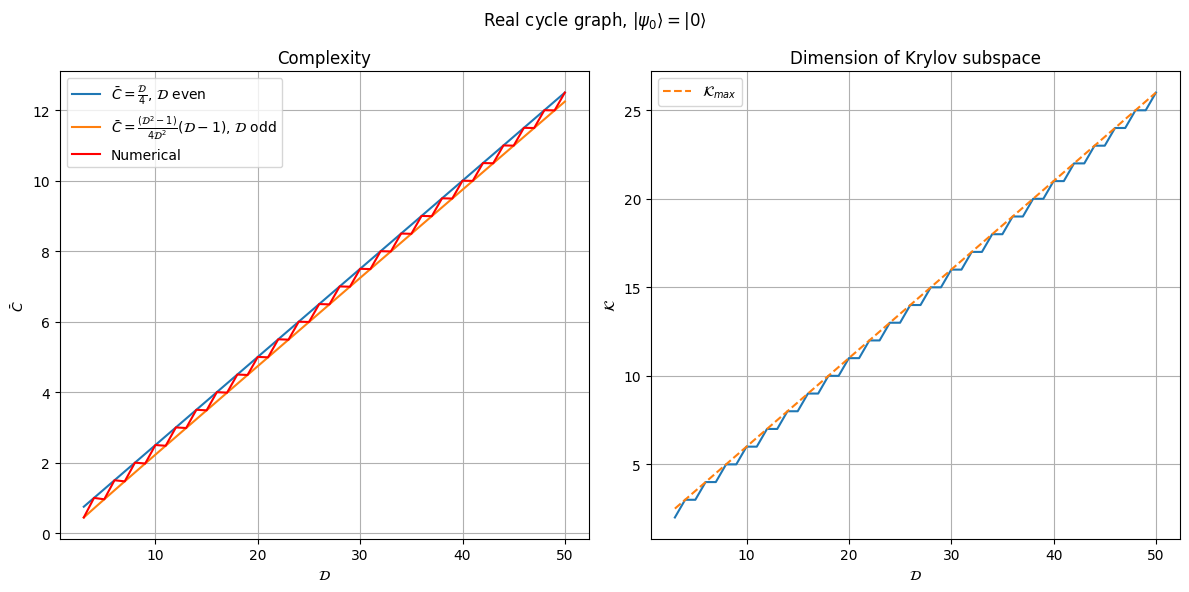

In [5]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

fig.suptitle(r"Real cycle graph, $|\psi_0 \rangle=|0 \rangle$")

axx[0].grid(True)
axx[0].plot(an_x,an_y_cycle_even, label=r"$\bar{C}=\frac{\mathcal{D}}{4}$, $\mathcal{D}$ even")
axx[0].plot(an_x,an_y_cycle_odd, label=r"$\bar{C}=\frac{(\mathcal{D}^2-1)}{4\mathcal{D}^2}(\mathcal{D}-1)$, $\mathcal{D}$ odd")
axx[0].plot(an_x, compl_cycle, label="Numerical", color="r")
axx[0].set_title(r"Complexity")
axx[0].set_ylabel(r"$\bar{C}$")
axx[0].set_xlabel(r"$\mathcal{D}$")
axx[0].legend()

axx[1].grid(True)
axx[1].plot(an_x,krylov_size)
axx[1].plot(an_x, an_x/2+1,linestyle="--", label=r"$\mathcal{K}_{max}$")
axx[1].set_title("Dimension of Krylov subspace")
axx[1].set_ylabel(r"$\mathcal{K}$")
axx[1].set_xlabel(r"$\mathcal{D}$")
axx[1].legend()

#fig.savefig("Real_cycles.pdf")
plt.show()

and non-real graphs ($\varphi \neq 0$). $\varphi =\frac{\pi}{100}$ is chosen such that the product $d\times\varphi$ is not an integer for any $d$ under scrutiny, in order to avoid having graphs that are quasi-gauge equivalent to the real ones.

In [6]:
threshold = 1e-15
initial = np.zeros(2, dtype=complex)
initial[0] = 1.0+0.j

phase = np.pi/100
w = np.array([0.,np.exp(phase*1.j)], dtype=complex)

an_x, compl_circ_cycle, krylov_size = circulant_routine(d_max=50, weights=w, initial=initial, threshold=threshold)

/tmp/ipykernel_6382/382704737.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  new_H, compl_cycle[i-dim_min] = kr.get_complexity(H_cycle, initial, threshold)


In [7]:
an_y_circ_cycle = (an_x-1.)/2.

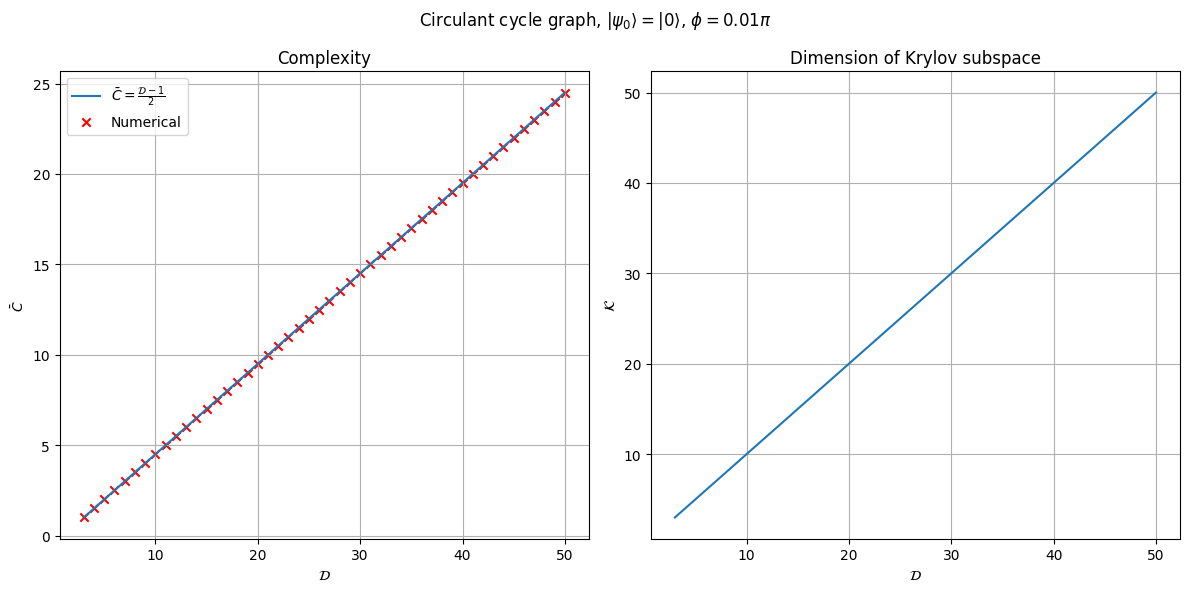

In [8]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

fig.suptitle(r"Circulant cycle graph, $|\psi_0 \rangle = | 0 \rangle$,"+f" $\phi=${phase/np.pi}$\pi$")

axx[0].grid(True)
#axx.plot(an_x,an_y_cycle_even, label="Analytical even dim")
axx[0].plot(an_x,an_y_circ_cycle, label=r"$\bar{C}=\frac{\mathcal{D}-1}{2}$")
axx[0].scatter(an_x, compl_circ_cycle, label="Numerical", marker="x", color="r")
axx[0].set_title(r"Complexity")
axx[0].set_ylabel(r"$\bar{C}$")
axx[0].set_xlabel(r"$\mathcal{D}$")
axx[0].legend()

axx[1].grid(True)
axx[1].plot(an_x, krylov_size)
axx[1].set_title("Dimension of Krylov subspace")
axx[1].set_ylabel(r"$\mathcal{K}$")
axx[1].set_xlabel(r"$\mathcal{D}$")

plt.show()

#fig.savefig("complex_cycles.pdf")

### Higher connectivity graphs

$\varphi = 0$

In [9]:
threshold=1e-5
initial = np.zeros(2, dtype=complex)
initial[0] = 1.0+0.j

w = np.array([0.,1.,1.])

an_x, compl_cycle, krylov_size = circulant_routine(d_max=50, weights=w, initial=initial, threshold=threshold)

/tmp/ipykernel_6382/382704737.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  new_H, compl_cycle[i-dim_min] = kr.get_complexity(H_cycle, initial, threshold)


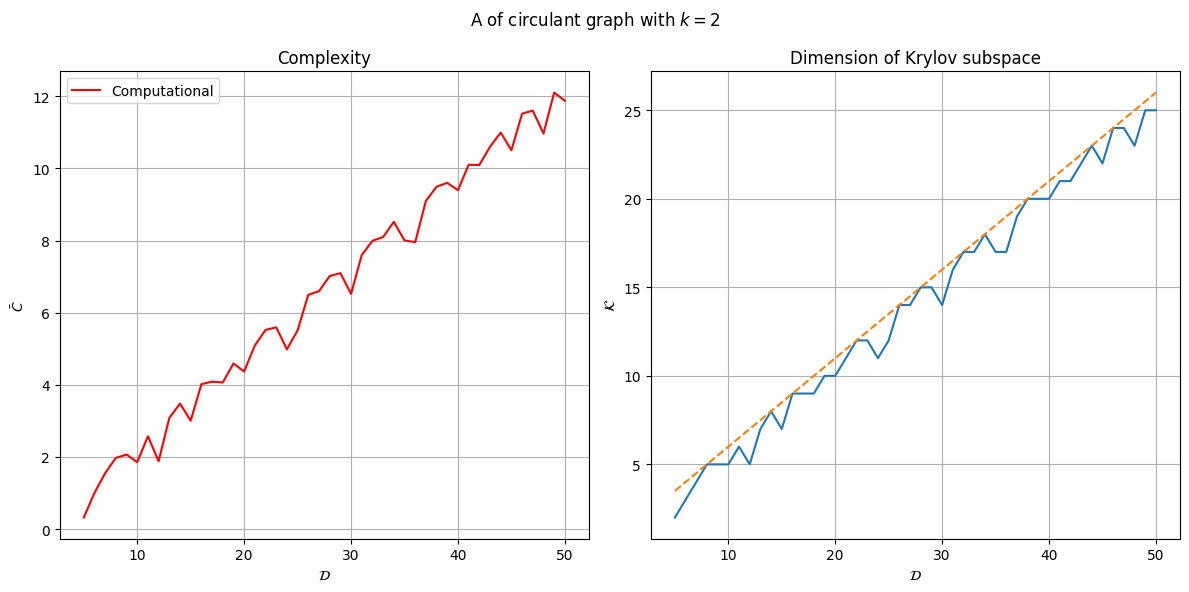

In [10]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

fig.suptitle("A of circulant graph with $k=2$")
axx[0].grid(True)
axx[0].plot(an_x, compl_cycle, label="Computational", color="r")
axx[0].set_title(r"Complexity")
axx[0].set_ylabel(r"$\bar{C}$")
axx[0].set_xlabel(r"$\mathcal{D}$")
axx[0].legend()

axx[1].grid(True)
axx[1].plot(an_x, krylov_size)
axx[1].plot(an_x, an_x/2+1,linestyle="--")
axx[1].set_title("Dimension of Krylov subspace")
axx[1].set_ylabel(r"$\mathcal{K}$")
axx[1].set_xlabel(r"$\mathcal{D}$")
plt.show()

### SOMETHING WEIRD HAPPENS

The pattern seems much more clear when a weighted graph is considered, with $w_2=2w_1$

In [11]:
threshold = 1e-7
initial = np.zeros(2, dtype=complex)
initial[0] = 1.0+0.j

w = np.array([0.,1.,2.])

an_x, compl_cycle, krylov_size = circulant_routine(d_max=50, weights=w, initial=initial, threshold=threshold)

/tmp/ipykernel_6382/382704737.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  new_H, compl_cycle[i-dim_min] = kr.get_complexity(H_cycle, initial, threshold)


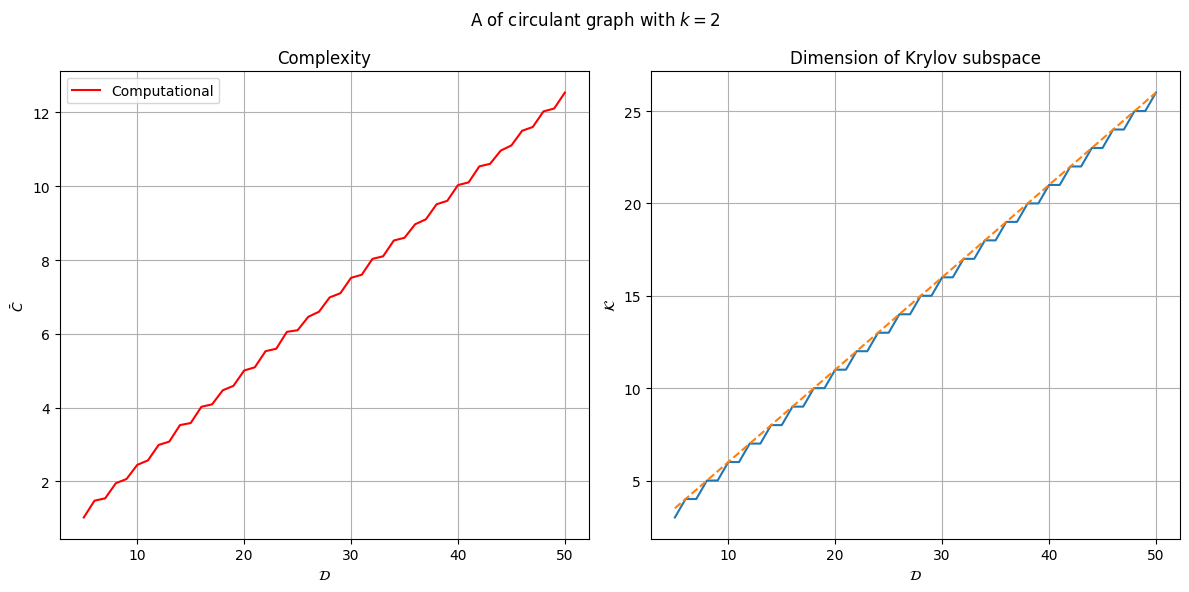

In [12]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

fig.suptitle("A of circulant graph with $k=2$")
axx[0].grid(True)
axx[0].plot(an_x, compl_cycle, label="Computational", color="r")
axx[0].set_title(r"Complexity")
axx[0].set_ylabel(r"$\bar{C}$")
axx[0].set_xlabel(r"$\mathcal{D}$")
axx[0].legend()

axx[1].grid(True)
axx[1].plot(an_x, krylov_size)
axx[1].plot(an_x, an_x/2+1,linestyle="--")
axx[1].set_title("Dimension of Krylov subspace")
axx[1].set_ylabel(r"$\mathcal{K}$")
axx[1].set_xlabel(r"$\mathcal{D}$")
plt.show()

In [13]:
threshold = 1e-6
initial = np.zeros(2, dtype=complex)
initial[0] = 1.0+0.j

w = np.array([0.,1.,1.,1.])

an_x, compl_cycle, krylov_size = circulant_routine(d_max=50, weights=w, initial=initial, threshold=threshold)

/tmp/ipykernel_6382/382704737.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  new_H, compl_cycle[i-dim_min] = kr.get_complexity(H_cycle, initial, threshold)


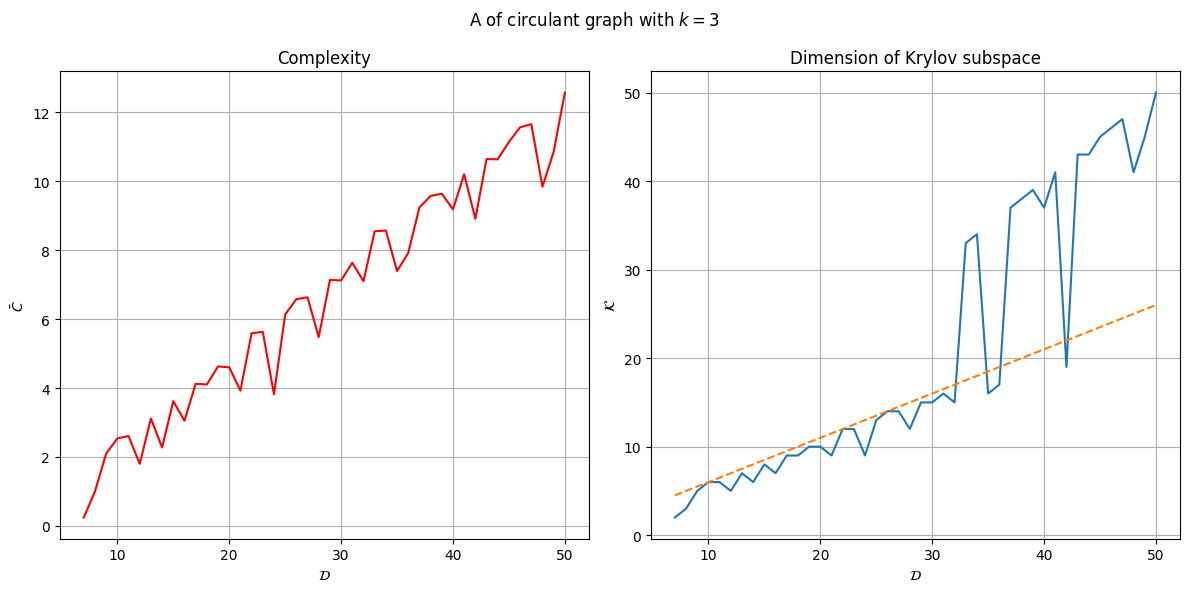

In [14]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

fig.suptitle("A of circulant graph with $k=3$")
axx[0].grid(True)
axx[0].plot(an_x, compl_cycle, color="r")
axx[0].set_title(r"Complexity")
axx[0].set_ylabel(r"$\bar{C}$")
axx[0].set_xlabel(r"$\mathcal{D}$")
#axx[0].legend()

axx[1].grid(True)
axx[1].plot(an_x, krylov_size)
axx[1].plot(an_x, an_x/2+1,linestyle="--")
axx[1].set_title("Dimension of Krylov subspace")
axx[1].set_ylabel(r"$\mathcal{K}$")
axx[1].set_xlabel(r"$\mathcal{D}$")
plt.show()

In [15]:
threshold=1e-6
initial = np.zeros(2, dtype=complex)
initial[0] = 1.0+0.j

w = np.array([0.,1.,1.,1.,1.])

an_x, compl_cycle, krylov_size = circulant_routine(d_max=50, weights=w, initial=initial, threshold=threshold)

/tmp/ipykernel_6382/382704737.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  new_H, compl_cycle[i-dim_min] = kr.get_complexity(H_cycle, initial, threshold)


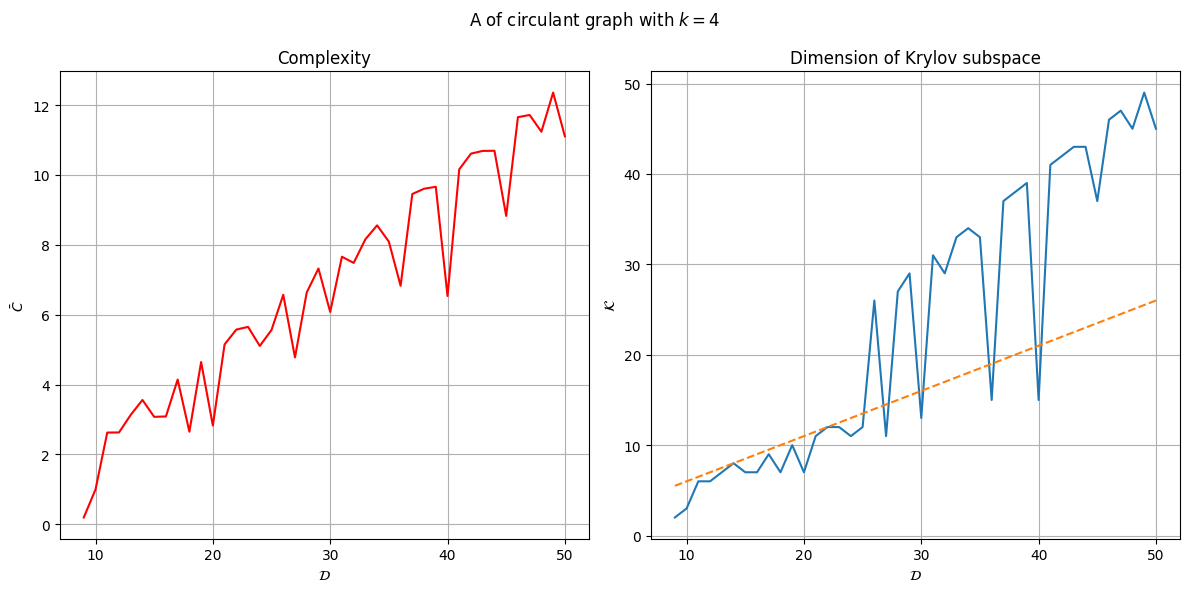

In [16]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

fig.suptitle("A of circulant graph with $k=4$")
axx[0].grid(True)
axx[0].plot(an_x, compl_cycle, color="r")
axx[0].set_title(r"Complexity")
axx[0].set_ylabel(r"$\bar{C}$")
axx[0].set_xlabel(r"$\mathcal{D}$")
#axx[0].legend()

axx[1].grid(True)
axx[1].plot(an_x, krylov_size)
axx[1].plot(an_x, an_x/2+1,linestyle="--")
axx[1].set_title("Dimension of Krylov subspace")
axx[1].set_ylabel(r"$\mathcal{K}$")
axx[1].set_xlabel(r"$\mathcal{D}$")
plt.show()

The Lanczos algorithm is likely numerically unstable: the dimension of the Krylov subspace should never exceed a value of $\frac{d}{2}+1$, because any non-chiral circulant Hamiltonian always exhibits a two-fold degeneracy $E_m = E_{d-m}$. 

$\mathcal{K}=d$ should be impossible, yet the algorithm gives consistently this result for any $d>d_{crit}$, where $d_{crit}$ decreases as the connectivity $k$ increases. 

My conjecture is that the numerical precision errors accumulate, such that at some point, when one should get $b_n=0$, or at least $b_n< \epsilon$, with $\epsilon \sim 10^{-6}$, the algorithm wrongfully computes $b_n > \epsilon$, and it goes on.

However, while $\mathcal{K}$ suddenly increases, $\bar{\mathcal{C}}$ doesn't: my conjecture is that, even though the Krylov coefficients are "imprecise", to say the least, the overlaps between the initial state and the "fake" Krylov states are so small that the overall error on $\bar{\mathcal{C}}$ is not so significant. 

The problem is still present and more severe for high dimensional Hamiltonians.

NOTES:
* Using data-type complex256 improves the situation
* Introducing naive reorthogonalization doesn't
* Increasing the threshold to 1e-3 doesn't improve
* Neither using complex512 does

## NOW WITH PHASES

In [17]:
threshold = 1e-15
phi1 = np.pi/73
phi2 = 2*phi1

initial = np.zeros(2, dtype=complex)
initial[0] = 1.0+0.j

w = np.array([0.,np.exp(phi1*1.j),np.exp(phi2*1.j)], dtype=complex)

an_x, compl_cycle, krylov_size = circulant_routine(d_max=50, weights=w, initial=initial, threshold=threshold)

/tmp/ipykernel_6382/382704737.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  new_H, compl_cycle[i-dim_min] = kr.get_complexity(H_cycle, initial, threshold)


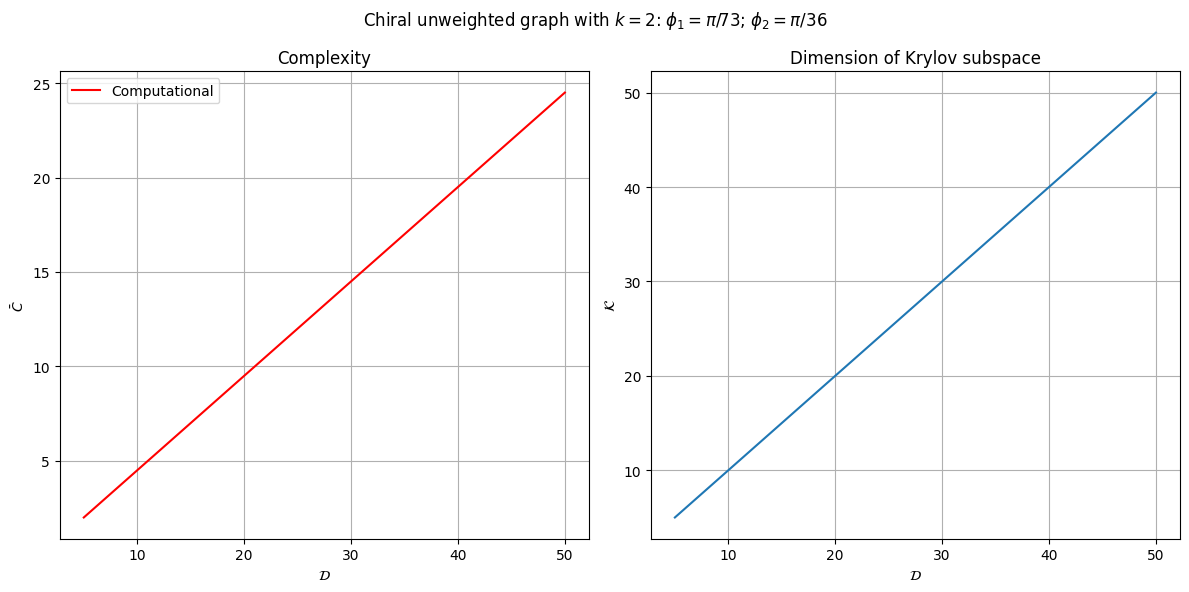

In [18]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

fig.suptitle("Chiral unweighted graph with $k=2$: "+f"$\phi_1=\pi/{format(np.pi/phi1, '.0f')}$; $\phi_2=\pi/{format(np.pi/phi2, '.0f')}$")
axx[0].grid(True)
axx[0].plot(an_x, compl_cycle, label="Computational", color="r")
axx[0].set_title(r"Complexity")
axx[0].set_ylabel(r"$\bar{C}$")
axx[0].set_xlabel(r"$\mathcal{D}$")
axx[0].legend()

axx[1].grid(True)
axx[1].plot(an_x, krylov_size)
#axx[1].plot(an_x, an_x/2+1,linestyle="--")
axx[1].set_title("Dimension of Krylov subspace")
axx[1].set_ylabel(r"$\mathcal{K}$")
axx[1].set_xlabel(r"$\mathcal{D}$")
plt.show()

The phases that restore the non-chiral degeneracy (i.e. restore T symmetry) are (at least some of them):

\begin{equation}
    \varphi_2 = 2\varphi_1,
\end{equation}
with
\begin{equation}
    \varphi_1 = \frac{2\pi n}{N}.
\end{equation}

COMMENT: Weird behaviour, the complexity seems to hold a pattern until a certain dimension, where it breaks. (Might be a numerical problem)

In [19]:
phi1 = np.pi/10
phi2 = 2*phi1

In [20]:
threshold = 1e-7
initial = np.zeros(2, dtype=complex)
initial[0] = 1.0+0.j

w = np.array([0.,np.exp(phi1*1.j),np.exp(phi2*1.j)], dtype=complex)

an_x, compl_cycle, krylov_size = circulant_routine(d_max=50, weights=w, initial=initial, threshold=threshold)

/tmp/ipykernel_6382/382704737.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  new_H, compl_cycle[i-dim_min] = kr.get_complexity(H_cycle, initial, threshold)


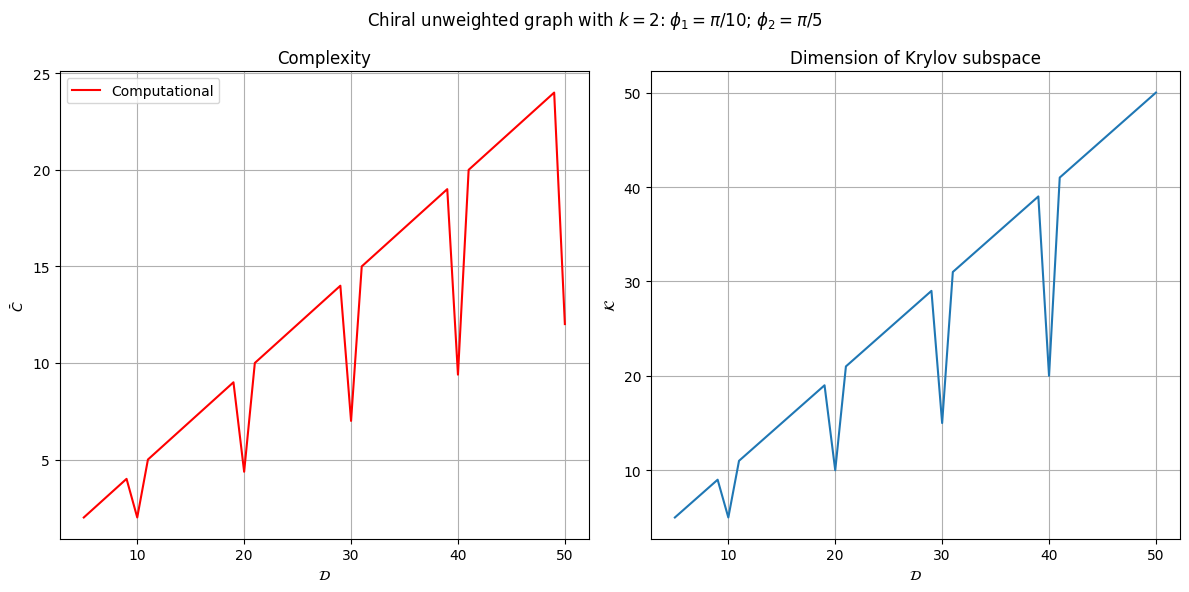

In [21]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

fig.suptitle("Chiral unweighted graph with $k=2$: "+f"$\phi_1=\pi/{format(np.pi/phi1, '.0f')}$; $\phi_2=\pi/{format(np.pi/phi2, '.0f')}$")
axx[0].grid(True)
axx[0].plot(an_x, compl_cycle, label="Computational", color="r")
axx[0].set_title(r"Complexity")
axx[0].set_ylabel(r"$\bar{C}$")
axx[0].set_xlabel(r"$\mathcal{D}$")
axx[0].legend()

axx[1].grid(True)
axx[1].plot(an_x, krylov_size)
#axx[1].plot(an_x, an_x/2+1,linestyle="--")
axx[1].set_title("Dimension of Krylov subspace")
axx[1].set_ylabel(r"$\mathcal{K}$")
axx[1].set_xlabel(r"$\mathcal{D}$")
plt.show()

# $k=2$, complexity as function of phases, for fixed dimension

We choose 3 prime values of $\mathcal{D}$, primely $\mathcal{D} = 11, \ 23, \ 31$.

$$ \varphi_1, \varphi_2 \in [0, 2\pi] $$

As usual, initial state is $\ket{0}$.

In [22]:
d_1 = 11

n_phis = 200
phis = np.linspace(start=0., stop=2*np.pi, num=n_phis)
threshold = 1e-7

initial = np.zeros(d_1, dtype=complex)
initial[0] = 1.0 + 0.j

compl_d1 = np.ndarray((n_phis,n_phis), dtype=float)

i=int(0)
j=int(0)
for phi1 in phis:
    for phi2 in phis:
        weights = np.zeros(int((d_1+1)/2), dtype=complex)
        weights[1] = np.exp(phi1*1.j)
        weights[2] = np.exp(phi2*1.j)
        H = gen.circulant_ham(weights, d_1)
        #print(H.real)
        compl_d1[i,j] = kr.get_complexity(H, initial, threshold)[1]
        #print(i,j)
        j+=1
    i+=1
    j=int(0)


/tmp/ipykernel_6382/2342972901.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  compl_d1[i,j] = kr.get_complexity(H, initial, threshold)[1]


In [23]:
d_2 = 23

n_phis = 200
phis = np.linspace(start=0., stop=2*np.pi, num=n_phis)
threshold = 1e-7

initial = np.zeros(d_2, dtype=complex)
initial[0] = 1.0 + 0.j

compl_d2 = np.ndarray((n_phis,n_phis), dtype=float)

i=int(0)
j=int(0)
for phi1 in phis:
    for phi2 in phis:
        weights = np.zeros(int((d_2+1)/2), dtype=complex)
        weights[1] = np.exp(phi1*1.j)
        weights[2] = np.exp(phi2*1.j)
        H = gen.circulant_ham(weights, d_2)
        #print(H.real)
        compl_d2[i,j] = kr.get_complexity(H, initial, threshold)[1]
        #print(i,j)
        j+=1
    i+=1
    j=int(0)

/tmp/ipykernel_6382/2665807610.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  compl_d2[i,j] = kr.get_complexity(H, initial, threshold)[1]


In [24]:
d_3 = 31

n_phis = 200
phis = np.linspace(start=0., stop=2*np.pi, num=n_phis)
threshold = 1e-7

initial = np.zeros(d_3, dtype=complex)
initial[0] = 1.0 + 0.j

compl_d3 = np.ndarray((n_phis,n_phis), dtype=float)

i=int(0)
j=int(0)
for phi1 in phis:
    for phi2 in phis:
        weights = np.zeros(int((d_3+1)/2), dtype=complex)
        weights[1] = np.exp(phi1*1.j)
        weights[2] = np.exp(phi2*1.j)
        H = gen.circulant_ham(weights, d_3)
        #print(H.real)
        compl_d3[i,j] = kr.get_complexity(H, initial, threshold)[1]
        #print(i,j)
        j+=1
    i+=1
    j=int(0)

/tmp/ipykernel_6382/93852055.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  compl_d3[i,j] = kr.get_complexity(H, initial, threshold)[1]


In [25]:
compls = [compl_d1, compl_d2, compl_d3]

dims = [d_1, d_2, d_3]

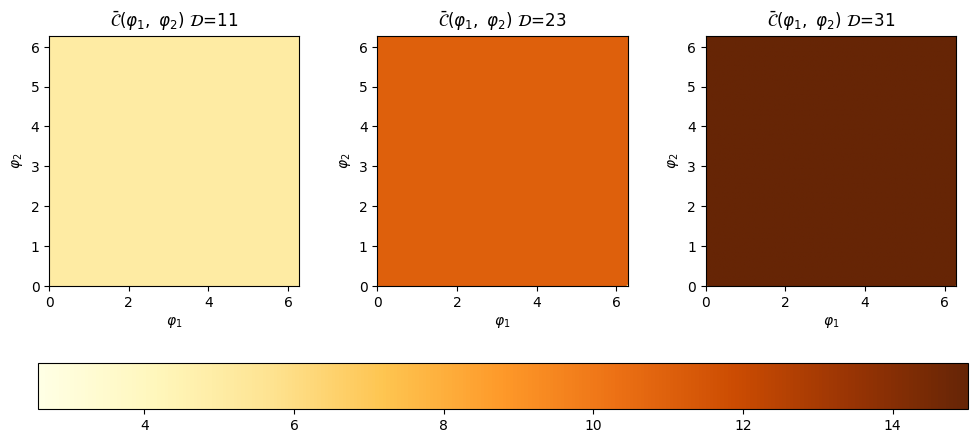

In [26]:
fig, axx = plt.subplots(1,3, figsize=(12,5))

vmin = min(c.min() for c in compls)
vmax = max(c.max() for c in compls)

#print(vmin, vmax)

for i in range(axx.size):
    ax = axx[i]
    ax.set_xlabel(r"$\varphi_1$")
    ax.set_ylabel(r"$\varphi_2$")
    ax.set_title(r"$\bar{\mathcal{C}}(\varphi_1, \ \varphi_2)$" +r" $\mathcal{D}$="+f"{dims[i]}")

    Z = compls[i].T

    im = ax.imshow(Z, extent=[phis[0], phis[-1], phis[0], phis[-1]], origin='lower', cmap='YlOrBr', vmin=vmin, vmax=vmax)
    #cbr = fig.colorbar(im, ax=ax)
    ax.set_aspect(1)

cbar = fig.colorbar(
    im,
    ax=axx,
    orientation= 'horizontal',
    pad=0.2
)

plt.show()

It doesn't depend on the values of the phases, up to a set of zero measure.

## Dependence on the coupling strength ratio

In [46]:
threshold = 1e-5

j_min = 0.01
j_max = 100

n_js = 10000

js = np.linspace(j_min, j_max, n_js)

complexities = np.array([np.zeros(n_js, dtype=float),np.zeros(n_js, dtype=float),np.zeros(n_js, dtype=float)])

dim_krylovs = np.array([np.zeros(n_js, dtype=float),np.zeros(n_js, dtype=float),np.zeros(n_js, dtype=float)])

#print(complexities[0])

for i in range(len(dims)):

    for j in range(len(js)):
        dim = dims[i]
        initial = np.zeros(dim, dtype=complex)
        initial[0] = 1.0 + 0.j

        weights = np.zeros(int((dim+1)/2), dtype=complex)
        weights[1] = 1.0
        weights[2] = js[j]

        H = gen.circulant_ham(weights, dim)

        #if(j==0 or j==len(js)-1):
        #    print(H)

        H_kryl, complexities[i][j] = kr.get_complexity(H, initial, threshold)
        dim_krylovs[i][j] = H_kryl.shape[0]
    

/tmp/ipykernel_6382/1948285986.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  H_kryl, complexities[i][j] = kr.get_complexity(H, initial, threshold)


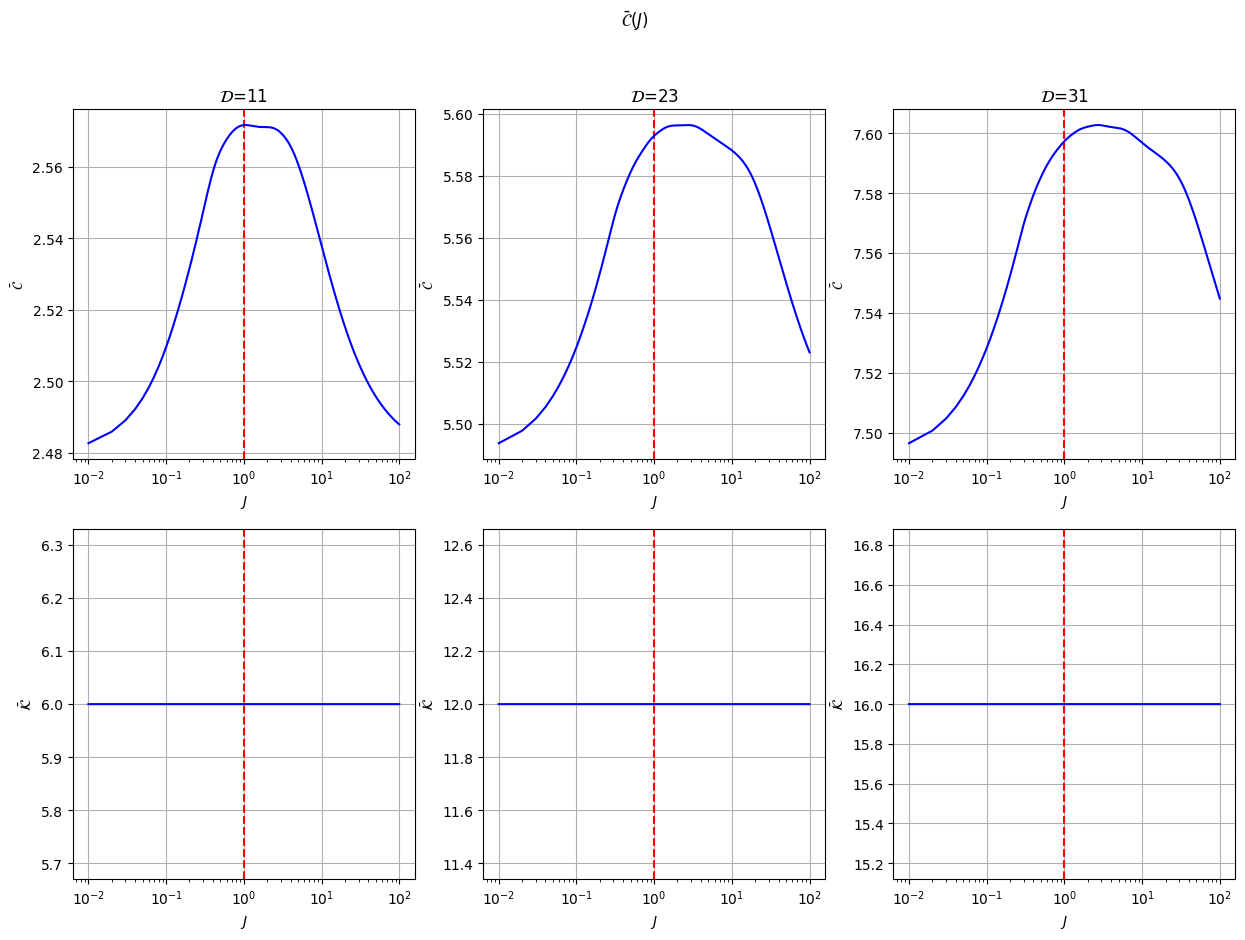

In [49]:
fig, axx = plt.subplots(2,3, figsize=(15,10))

fig.suptitle(r"$\bar{\mathcal{C}}(J)$")

for i in range(axx.shape[1]):
    ax = axx[0][i]

    ax.grid(True)
    ax.set_xlabel(r"$J$")
    ax.set_ylabel(r"$\bar{\mathcal{C}}$")
    ax.set_title("$\mathcal{D}$="+f"{dims[i]}")
    ax.set_xscale('log')
    
    ax.axvline(x=1.0, color='red', linestyle='--')

    y = complexities[i]

    ax.plot(js, y, linestyle='-', color='blue')

for i in range(axx.shape[1]):
    ax = axx[1][i]

    ax.grid(True)
    ax.set_xlabel(r"$J$")
    ax.set_ylabel(r"$\bar{\mathcal{K}}$")
    #ax.set_title("$\mathcal{D}$="+f"{dims[i]}")
    ax.set_xscale('log')
    
    ax.axvline(x=1.0, color='red', linestyle='--')

    y = dim_krylovs[i]

    ax.plot(js, y, linestyle='-', color='blue')
